# Lab 2 — Hàng đợi M/M/n/K/N
**Môn:** NT531 — Đánh giá hiệu năng Mạng máy tính

| Thông tin | |
|---|---|
| **Họ và tên** | *(điền tên)* |
| **MSSV** | *(điền MSSV)* |

Notebook này chuyển nội dung từ `lab2_instruction.pdf` và khung tính `lab2_Student.xlsx`
sang dạng Jupyter notebook để sinh viên có thể tính toán, kiểm tra từng bước và thay đổi
tham số trực tiếp bằng Python.


> **Ghi chú đối chiếu lý thuyết:** Các công thức trong notebook này đã được rà lại theo
> `lecture_02_arrival processes and queuing systems (1).pdf`, chủ yếu ở phần
> `M/M/n/K/N` và `General birth and death process` (trang 35-40 của slide text).
> Cụ thể:
> - `λ_x`, `μ_x`, `P_x` dùng đúng mô hình birth-death với chuẩn hoá `P(0)`.
> - `P{immediate service}`, `P{delayed service}`, `P{loss}` được tính theo **arrival-weighted**
>   xác suất `Σ λ_x P(x) / λ_T`, không phải chỉ cộng đơn thuần theo `P(x)`.
> - `E{q}` và `E{q|x>n}` bám theo định nghĩa ở phần `General birth and death process`.
> - `t_w` và `t_system` trong notebook được suy ra bằng Little's law với
>   `throughput = λ_T (1 - P{loss})`.


## Cài đặt và import thư viện
Chạy cell bên dưới để import các thư viện cần thiết. Nếu môi trường chưa có thư viện, có
thể bỏ comment dòng `pip install`.


In [1]:
# Cài đặt thư viện (bỏ comment nếu cần)
# !pip install numpy pandas matplotlib

import os
import tempfile
import warnings

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mplconfig-"))
warnings.filterwarnings(
    "ignore",
    message="FigureCanvasAgg is non-interactive, and thus cannot be shown",
)

import numpy as np
import pandas as pd
import matplotlib

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


Matplotlib is building the font cache; this may take a moment.


---
# PHẦN 1: MÔ HÌNH VÀ CÔNG THỨC
---

## Ký hiệu tổng quát `A/B/n/K/N/X`
- `A`: quá trình đến (arrival process)
- `B`: quá trình phục vụ (service process)
- `n`: số server
- `K`: sức chứa tối đa của hệ thống
- `N`: số nguồn khách hàng
- `X`: quy luật phục vụ hàng đợi

Trong lab này ta xét mô hình **M/M/n/K/N**:
- Quá trình đến là Markovian
- Thời gian phục vụ là Markovian
- Có `n` server
- Tối đa `K` khách trong hệ thống
- Có `N` nguồn khách hàng, với `N=0` được hiểu là nguồn vô hạn

## Các bước tính theo tài liệu lab 2
1. Tính `λ = A / tm`
2. Tính `q(x)`:
   - Nếu `x < n` thì `q = 0`
   - Ngược lại `q = x - n`
3. Tính `λ_x`
   - Nếu `N = 0` thì `λ_x = λ`
   - Nếu `N > 0` thì `λ_x = λ (N - x)`
4. Tính `μ_x`
   - Nếu `x > n` thì `μ_x = nμ`
   - Nếu `x <= n` thì `μ_x = xμ`
5. Tính hạng không chuẩn hoá `T_x`
   - `T_0 = 1`
   - `T_x = T_(x-1) * (λ_(x-1) / μ_x)`
6. Chuẩn hoá để lấy `P_x = T_x / ΣT_i`

Trong notebook này, ta dùng đúng tinh thần của Excel và PDF:
- `λ = A / tm`
- `μ = 1 / tm`
- Không gian trạng thái là `x = 0, 1, ..., min(K, N)` nếu `N > 0`
- Nếu `N = 0` thì không gian trạng thái là `x = 0, 1, ..., K`


In [2]:
# Bộ tham số mẫu lấy từ file Excel lab2_Student.xlsx
A = 4
n = 5
tm = 3
K = 15
N = 18
discipline = "FIFO"

lam = A / tm
mu = 1 / tm

print(f"A = {A}")
print(f"n = {n}")
print(f"tm = {tm}")
print(f"K = {K}")
print(f"N = {N} (N=0 nghĩa là nguồn vô hạn)")
print(f"Queue discipline = {discipline}")
print(f"λ = A/tm = {lam:.6f}")
print(f"μ = 1/tm = {mu:.6f}")


A = 4
n = 5
tm = 3
K = 15
N = 18 (N=0 nghĩa là nguồn vô hạn)
Queue discipline = FIFO
λ = A/tm = 1.333333
μ = 1/tm = 0.333333


In [3]:
# Kiểm tra nhanh tính hợp lệ của tham số
if n <= 0:
    raise ValueError("n phải > 0")
if tm <= 0:
    raise ValueError("tm phải > 0")
if K < 0:
    raise ValueError("K phải >= 0")
if A < 0 or N < 0:
    raise ValueError("A và N phải >= 0")
if N > 0 and K > N:
    print("Lưu ý: với nguồn hữu hạn, số trạng thái hợp lệ dừng ở min(K, N).")


---
# PHẦN 2: LẬP BẢNG TRẠNG THÁI TƯƠNG ĐƯƠNG EXCEL
---

Cell dưới đây xây dựng lại toàn bộ các cột trong file Excel:
- `x`
- `q`
- `λ_x`
- `μ_x`
- `T_x`
- `P_x`
- `λ_x * P_x`
- `(x-n) * P(x)`


In [4]:
def build_mmnkn_table(A, n, tm, K, N):
    """Tạo bảng trạng thái và các chỉ số đầu ra cho mô hình M/M/n/K/N.

    Parameters
    ----------
    A : float
        Cường độ đầu vào theo đề bài, với λ = A / tm.
    n : int
        Số server phục vụ song song.
    tm : float
        Thời gian mốc dùng để suy ra λ = A/tm và μ = 1/tm.
    K : int
        Sức chứa tối đa của hệ thống.
    N : int
        Số nguồn khách hàng; N = 0 nghĩa là nguồn vô hạn.

    Returns
    -------
    table : pandas.DataFrame
        Bảng trạng thái tương đương các cột trong Excel.
    outputs : dict
        Tập các chỉ số tổng hợp như P{immediate service}, P{delay}, P{loss}, E{q}, E{x}, t_w.
    """
    # Suy ra tốc độ đến và tốc độ phục vụ từ tham số đầu bài.
    lam = A / tm
    mu = 1 / tm

    # Với nguồn hữu hạn, số trạng thái tối đa không thể vượt quá N.
    # Với nguồn vô hạn (N = 0), không gian trạng thái dừng ở K.
    max_state = K if N == 0 else min(K, N)
    states = np.arange(max_state + 1, dtype=int)

    # q(x) = số khách đang chờ trong hàng đợi tại trạng thái x.
    # Nếu x <= n thì mọi khách đều đang được phục vụ, chưa có hàng đợi.
    q = np.maximum(states - n, 0)

    # λ_x = tốc độ đến tại trạng thái x.
    # - N = 0: arrival rate không đổi theo trạng thái.
    # - N > 0: chỉ các nguồn còn rảnh (N - x) mới có thể sinh thêm khách.
    if N == 0:
        lambda_x = np.full(states.shape, lam, dtype=float)
    else:
        lambda_x = lam * np.maximum(N - states, 0)

    # μ_x = tốc độ phục vụ tổng tại trạng thái x.
    # Tối đa chỉ có n server hoạt động đồng thời.
    mu_x = np.minimum(states, n) * mu

    # T_x là hạng không chuẩn hoá của phân phối trạng thái.
    # Ta dùng truy hồi:
    #   T_0 = 1
    #   T_x = T_(x-1) * λ_(x-1) / μ_x
    T_x = np.zeros(states.shape, dtype=float)
    T_x[0] = 1.0
    for i in range(1, len(states)):
        if mu_x[i] == 0:
            T_x[i] = 0.0
        else:
            T_x[i] = T_x[i - 1] * (lambda_x[i - 1] / mu_x[i])

    # Chuẩn hoá T_x để thu được xác suất trạng thái P_x.
    sum_T = T_x.sum()
    P_x = T_x / sum_T

    # λ_x * P_x là mức đóng góp của từng trạng thái vào tổng tốc độ đến hữu hiệu λ_T.
    lambda_x_P_x = lambda_x * P_x

    # (x - n) * P_x là thành phần đóng góp của trạng thái x vào E{q}.
    queue_term = q * P_x

    table = pd.DataFrame(
        {
            "x": states,
            "q": q,
            "lambda_x": lambda_x,
            "mu_x": mu_x,
            "T_x": T_x,
            "P_x": P_x,
            "lambda_x*P_x": lambda_x_P_x,
            "(x-n)*P_x": queue_term,
        }
    )

    # λ_T là tổng tốc độ đến trung bình khi cân theo xác suất trạng thái.
    lambda_T = lambda_x_P_x.sum()

    # Xác suất được phục vụ ngay: arrival xảy ra khi hệ thống còn server rảnh (x < n).
    p_immediate_service = (
        lambda_x_P_x[states < n].sum() / lambda_T if lambda_T > 0 else 0.0
    )

    # Xác suất phải chờ: arrival xảy ra khi tất cả server bận nhưng hệ còn chưa đầy.
    p_delayed_service = (
        lambda_x_P_x[(states >= n) & (states < K)].sum() / lambda_T
        if lambda_T > 0
        else 0.0
    )

    # Xác suất loss: arrival gặp đúng trạng thái đầy K.
    p_loss = (
        lambda_x_P_x[states == K].sum() / lambda_T
        if lambda_T > 0 and np.any(states == K)
        else 0.0
    )

    # Một số xác suất trạng thái phụ để bám sát sheet Excel.
    p_x_eq_k = P_x[states == K].sum() if np.any(states == K) else 0.0
    p_n_minus_1_lt_x_lt_k = P_x[(states > n - 1) & (states < K)].sum()
    p_x_lt_n = P_x[states < n].sum()

    # E{q} là độ dài hàng đợi trung bình trên mọi trạng thái.
    E_q_all = queue_term.sum()

    # E{q | x > n} là độ dài hàng đợi trung bình khi thực sự tồn tại hàng đợi.
    prob_queue_exists = P_x[states > n].sum()
    E_q_given_queue = E_q_all / prob_queue_exists if prob_queue_exists > 0 else 0.0

    # E{x} là số khách trung bình trong toàn hệ thống.
    E_x = np.sum(states * P_x)

    # Throughput là tốc độ khách thực sự đi vào hệ sau khi trừ phần bị loss.
    throughput = lambda_T * (1.0 - p_loss)

    # Theo Little, t_w = E{q} / throughput và t_system = E{x} / throughput.
    t_w = E_q_all / throughput if throughput > 0 else 0.0
    t_system = E_x / throughput if throughput > 0 else 0.0

    outputs = {
        "lambda": lam,
        "mu": mu,
        "sum_Tx": sum_T,
        "lambda_T": lambda_T,
        "P_immediate_service": p_immediate_service,
        "P_delayed_service": p_delayed_service,
        "P_loss": p_loss,
        "P_x_eq_K": p_x_eq_k,
        "P_n_minus_1_lt_x_lt_K": p_n_minus_1_lt_x_lt_k,
        "P_x_lt_n": p_x_lt_n,
        "E_q_all_states": E_q_all,
        "E_q_given_queue_exists": E_q_given_queue,
        "E_x": E_x,
        "throughput": throughput,
        "t_w": t_w,
        "t_system": t_system,
        "prob_queue_exists": prob_queue_exists,
    }

    return table, outputs


In [5]:
def sweep_parameter_grid(A_values, n, tm, K, N_values):
    rows = []
    for A_value in A_values:
        for N_value in N_values:
            _, out = build_mmnkn_table(A=A_value, n=n, tm=tm, K=K, N=N_value)
            rows.append(
                {
                    "A": A_value,
                    "N": N_value,
                    "P_immediate": out["P_immediate_service"],
                    "P_delay": out["P_delayed_service"],
                    "P_loss": out["P_loss"],
                    "E_q": out["E_q_all_states"],
                    "E_x": out["E_x"],
                    "t_w": out["t_w"],
                }
            )
    return pd.DataFrame(rows)


def plot_metric_heatmap(df, metric, title, cmap="viridis"):
    pivot = df.pivot(index="A", columns="N", values=metric).sort_index()
    fig, ax = plt.subplots(figsize=(10, 4.8))
    im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("N")
    ax.set_ylabel("A")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])
    fig.colorbar(im, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()


In [6]:
state_table, outputs = build_mmnkn_table(A=A, n=n, tm=tm, K=K, N=N)
state_table


,x,q,lambda_x,mu_x,T_x,P_x,lambda_x*P_x,(x-n)*P_x
0,0,0,24.000000,0.000000,1.000000,0.000000,0.000000,0.000000
1,1,0,22.666667,0.333333,72.000000,0.000000,0.000000,0.000000
2,2,0,21.333333,0.666667,2448.000000,0.000000,0.000000,0.000000
3,3,0,20.000000,1.000000,52224.000000,0.000000,0.000000,0.000000
4,4,0,18.666667,1.333333,783360.000000,0.000000,0.000000,0.000000
5,5,0,17.333333,1.666667,8773632.000000,0.000000,0.000000,0.000000
6,6,1,16.000000,1.666667,91245772.800000,0.000000,0.000001,0.000000
7,7,2,14.666667,1.666667,875959418.880000,0.000001,0.000009,0.000001
8,8,3,13.333333,1.666667,7708442886.144002,0.000006,0.000075,0.000017
9,9,4,12.000000,1.666667,61667543089.152016,0.000045,0.000537,0.000179


In [7]:
# Kiểm tra tổng xác suất
print(f"Tổng P_x = {state_table['P_x'].sum():.8f}")
print(f"Tổng λ_x * P_x = λ_T = {outputs['lambda_T']:.8f}")


Tổng P_x = 1.00000000
Tổng λ_x * P_x = λ_T = 4.50287513


---
# PHẦN 3: CÁC CHỈ SỐ ĐẦU RA
---

Từ bảng trạng thái, ta tính các chỉ số yêu cầu trong đề lab:
- `P{immediate service}`
- `P{delay}`
- `P{loss}`
- `E{q}`
- `t_w`
- `E{x}`

Ngoài ra, notebook còn in thêm một số xác suất trạng thái để bám sát bố cục của file Excel.


In [8]:
summary = pd.Series(
    {
        "λ": outputs["lambda"],
        "μ": outputs["mu"],
        "sum(Tx)": outputs["sum_Tx"],
        "λ_T": outputs["lambda_T"],
        "P{immediate service}": outputs["P_immediate_service"],
        "P{delay}": outputs["P_delayed_service"],
        "P{loss}": outputs["P_loss"],
        "P{x=K}": outputs["P_x_eq_K"],
        "P{n-1 < x < K}": outputs["P_n_minus_1_lt_x_lt_K"],
        "P{x<n}": outputs["P_x_lt_n"],
        "E{q|all state}": outputs["E_q_all_states"],
        "E{q|queue exist}": outputs["E_q_given_queue_exists"],
        "E{x}": outputs["E_x"],
        "Throughput": outputs["throughput"],
        "t_w": outputs["t_w"],
        "t_system": outputs["t_system"],
    }
)

summary.to_frame(name="Giá trị")


,Giá trị
λ,1.333333
μ,0.333333
sum(Tx),1378891811088662.250000
λ_T,4.502875
P{immediate service},0.000000
P{delay},0.370134
P{loss},0.629866
P{x=K},0.709052
P{n-1 < x < K},0.290948
P{x<n},0.000000


In [9]:
# Kiểm tra ba xác suất theo phía arrival có cộng thành 1 không
p_total = (
    outputs["P_immediate_service"]
    + outputs["P_delayed_service"]
    + outputs["P_loss"]
)
print(f"P{{immediate}} + P{{delay}} + P{{loss}} = {p_total:.8f}")


P{immediate} + P{delay} + P{loss} = 1.00000000


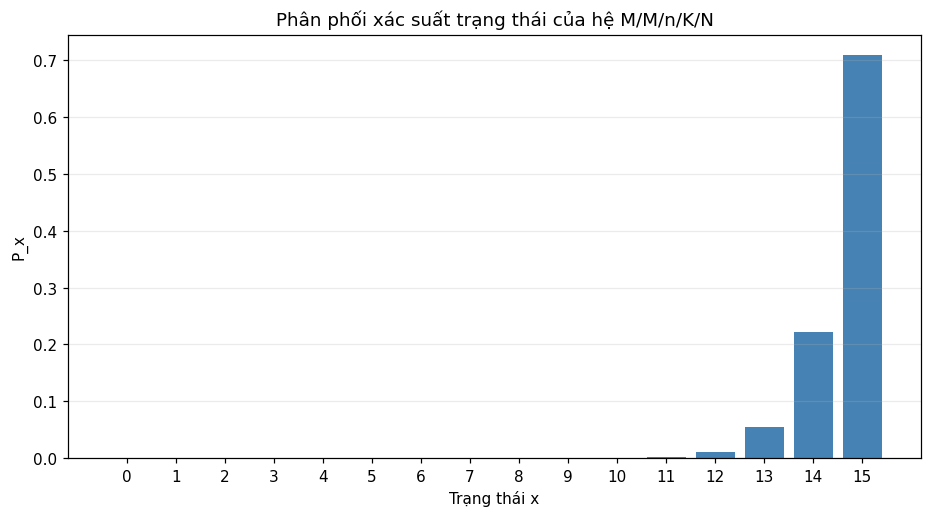

In [10]:
# Vẽ phân phối trạng thái P_x
plt.bar(state_table["x"], state_table["P_x"], color="steelblue")
plt.xlabel("Trạng thái x")
plt.ylabel("P_x")
plt.title("Phân phối xác suất trạng thái của hệ M/M/n/K/N")
plt.xticks(state_table["x"])
plt.grid(axis="y", alpha=0.25)
plt.show()


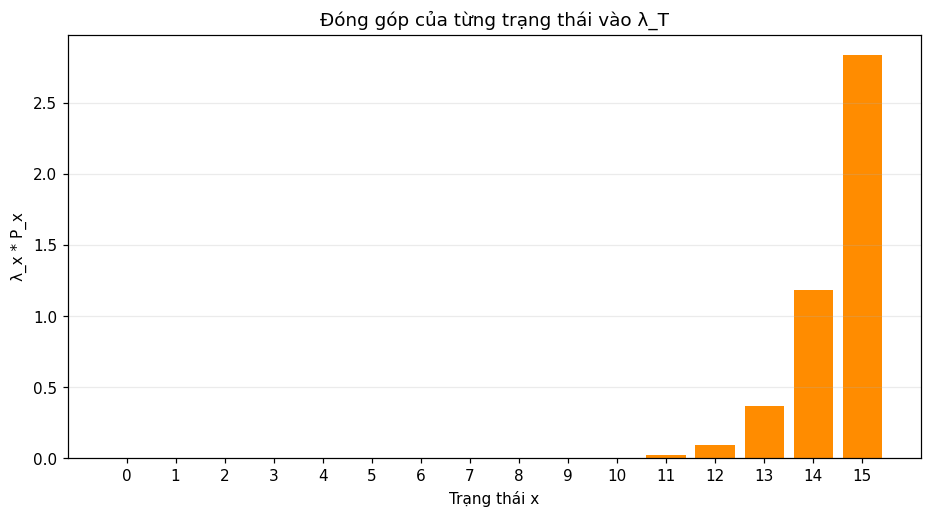

In [11]:
# Vẽ λ_x * P_x để thấy trạng thái nào đóng góp nhiều vào tổng tốc độ đến λ_T
plt.bar(state_table["x"], state_table["lambda_x*P_x"], color="darkorange")
plt.xlabel("Trạng thái x")
plt.ylabel("λ_x * P_x")
plt.title("Đóng góp của từng trạng thái vào λ_T")
plt.xticks(state_table["x"])
plt.grid(axis="y", alpha=0.25)
plt.show()


---
# PHẦN 4: THỬ NGHIỆM THAY ĐỔI THAM SỐ
---

Cell dưới đây giúp sinh viên thay đổi một vài bộ tham số và so sánh nhanh các chỉ số chính.
Có thể thêm hoặc bớt các cấu hình trong danh sách `configs`.


In [12]:
configs = [
    {"label": "Mẫu Excel", "A": 4, "n": 5, "tm": 3, "K": 15, "N": 18},
    {"label": "Tăng server", "A": 4, "n": 6, "tm": 3, "K": 15, "N": 18},
    {"label": "Giảm sức chứa", "A": 4, "n": 5, "tm": 3, "K": 10, "N": 18},
    {"label": "Nguồn vô hạn", "A": 4, "n": 5, "tm": 3, "K": 15, "N": 0},
]

comparison_rows = []
for cfg in configs:
    _, out = build_mmnkn_table(**{k: cfg[k] for k in ["A", "n", "tm", "K", "N"]})
    comparison_rows.append(
        {
            "Cấu hình": cfg["label"],
            "P{immediate}": out["P_immediate_service"],
            "P{delay}": out["P_delayed_service"],
            "P{loss}": out["P_loss"],
            "E{q}": out["E_q_all_states"],
            "E{x}": out["E_x"],
            "t_w": out["t_w"],
        }
    )

pd.DataFrame(comparison_rows)


,Cấu hình,P{immediate},P{delay},P{loss},E{q},E{x},t_w
0,Mẫu Excel,0.000000,0.370134,0.629866,9.622844,14.622844,5.773706
1,Tăng server,0.000000,0.432302,0.567698,8.530207,14.530207,4.265104
2,Giảm sức chứa,0.000003,0.153263,0.846734,4.844223,9.844221,2.906535
3,Nguồn vô hạn,0.468171,0.519334,0.012494,1.577571,5.527594,1.198148


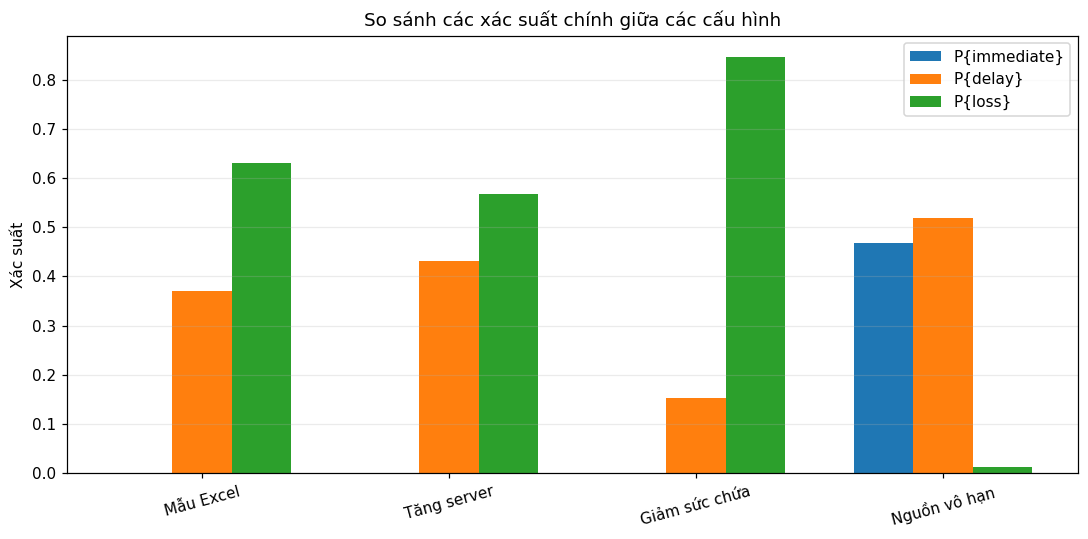

In [13]:
comparison_df = pd.DataFrame(comparison_rows)

x = np.arange(len(comparison_df))
width = 0.24

plt.bar(x - width, comparison_df["P{immediate}"], width=width, label="P{immediate}")
plt.bar(x, comparison_df["P{delay}"], width=width, label="P{delay}")
plt.bar(x + width, comparison_df["P{loss}"], width=width, label="P{loss}")
plt.xticks(x, comparison_df["Cấu hình"], rotation=15)
plt.ylabel("Xác suất")
plt.title("So sánh các xác suất chính giữa các cấu hình")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


---
# PHẦN 5: BỔ SUNG CHO LỚP .1
---

## Yêu cầu bổ sung

**Câu A:** Thay đổi các thông số `A`, `K`, `N` để xét hai trường hợp:
- Hệ thống hàng đợi rảnh và cường độ thấp: tìm `A` và `N` với điều kiện `A < 1` và `n < N <= K`
  sao cho `P{immediate service}` tiến gần `1` và `P{loss} = 0`.
- Hệ thống hàng đợi chưa bị quá tải và cường độ cao: tìm `A` và `N` với điều kiện `A > 1` và
  `n < N <= K` sao cho `P{immediate service}` càng gần `1` càng tốt và `P{loss} = 0`.

**Câu B:** Với thông số mặc định trong file Excel nhưng thay `A = 3`, hãy giải thích vì sao khi
`N = n = 5` thì `P{immediate service} = 1`, và khi tăng `N = 6, 7, 8, ..., K` thì xác suất này
**giảm nhanh** theo đúng mô hình của lab2.


### Câu A — Quét tham số và chọn các cấu hình tiêu biểu

Ta quét trên một lưới tham số để tìm các cấu hình phù hợp nhất. Với `P{loss}`, trong mô hình nguồn
hữu hạn, nhiều trường hợp sẽ bằng `0` khi trạng thái đầy không còn phát sinh arrival mới.
Điều quan trọng hơn là quan sát xem `P{immediate service}` tiến sát `1` đến mức nào.


In [14]:
N_values = np.arange(n + 1, K + 1)
low_A_values = np.round(np.arange(0.1, 1.0, 0.1), 2)
high_A_values = np.array([1.01, 1.05, 1.10, 1.20, 1.50, 2.0, 3.0, 4.0])

low_grid = sweep_parameter_grid(low_A_values, n=n, tm=tm, K=K, N_values=N_values)
high_grid = sweep_parameter_grid(high_A_values, n=n, tm=tm, K=K, N_values=N_values)

low_candidates = (
    low_grid.query("P_loss < 1e-12")
    .sort_values(["P_immediate", "A", "N"], ascending=[False, True, True])
    .head(10)
)
high_candidates = (
    high_grid.query("P_loss < 1e-12")
    .sort_values(["P_immediate", "A", "N"], ascending=[False, True, True])
    .head(10)
)

print("Các cấu hình tốt cho trường hợp cường độ thấp:")
print(low_candidates.reset_index(drop=True).to_string(index=False))

print("Các cấu hình tốt cho trường hợp cường độ cao:")
print(high_candidates.reset_index(drop=True).to_string(index=False))


Các cấu hình tốt cho trường hợp cường độ thấp:
       A  N  P_immediate  P_delay   P_loss      E_q      E_x      t_w
0.100000  6     0.999994 0.000006 0.000000 0.000001 0.545455 0.000004
0.100000  7     0.999965 0.000035 0.000000 0.000004 0.636368 0.000021
0.100000  8     0.999888 0.000112 0.000000 0.000017 0.727288 0.000070
0.200000  6     0.999871 0.000129 0.000000 0.000026 1.000021 0.000077
0.100000  9     0.999722 0.000278 0.000000 0.000048 0.818226 0.000177
0.100000 10     0.999420 0.000580 0.000000 0.000114 0.909195 0.000377
0.300000  6     0.999346 0.000654 0.000000 0.000181 1.384755 0.000393
0.200000  7     0.999331 0.000669 0.000000 0.000162 1.166802 0.000417
0.100000 11     0.998923 0.001077 0.000000 0.000238 1.000217 0.000715
0.100000 12     0.998165 0.001835 0.000000 0.000452 1.091320 0.001244
Các cấu hình tốt cho trường hợp cường độ cao:
       A  N  P_immediate  P_delay   P_loss      E_q      E_x      t_w
1.010000  6     0.967965 0.032035 0.000000 0.019255 3.024505 0.0192

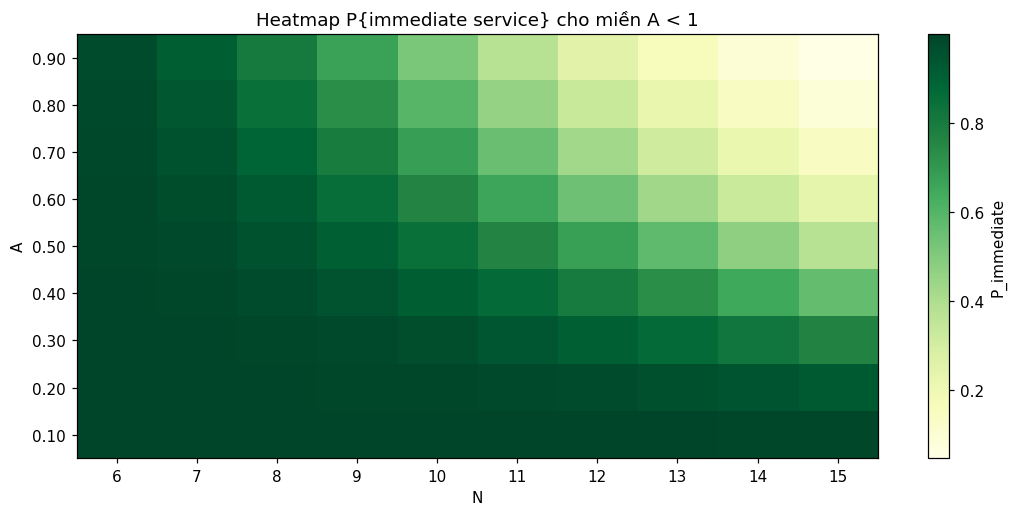

In [15]:
plot_metric_heatmap(
    low_grid,
    metric="P_immediate",
    title="Heatmap P{immediate service} cho miền A < 1",
    cmap="YlGn",
)


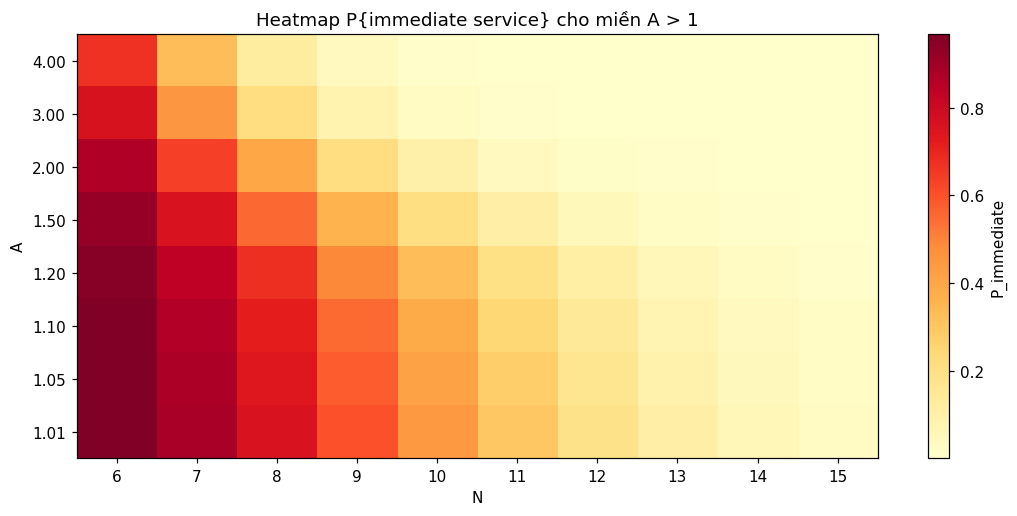

In [16]:
plot_metric_heatmap(
    high_grid,
    metric="P_immediate",
    title="Heatmap P{immediate service} cho miền A > 1",
    cmap="YlOrRd",
)


In [17]:
# Chọn 2 cấu hình đại diện để giải thích trực quan
representative_configs = pd.DataFrame(
    [
        {"Trường hợp": "Cường độ thấp", "A": 0.2, "N": 6},
        {"Trường hợp": "Cường độ cao", "A": 1.01, "N": 6},
    ]
)

rep_rows = []
for _, row in representative_configs.iterrows():
    _, out = build_mmnkn_table(A=row["A"], n=n, tm=tm, K=K, N=int(row["N"]))
    rep_rows.append(
        {
            "Trường hợp": row["Trường hợp"],
            "A": row["A"],
            "N": int(row["N"]),
            "P{immediate}": out["P_immediate_service"],
            "P{delay}": out["P_delayed_service"],
            "P{loss}": out["P_loss"],
            "E{q}": out["E_q_all_states"],
            "E{x}": out["E_x"],
            "t_w": out["t_w"],
        }
    )

rep_df = pd.DataFrame(rep_rows)
rep_df


,Trường hợp,A,N,P{immediate},P{delay},P{loss},E{q},E{x},t_w
0,Cường độ thấp,0.200000,6,0.999871,0.000129,0.000000,0.000026,1.000021,0.000077
1,Cường độ cao,1.010000,6,0.967965,0.032035,0.000000,0.019255,3.024505,0.019221


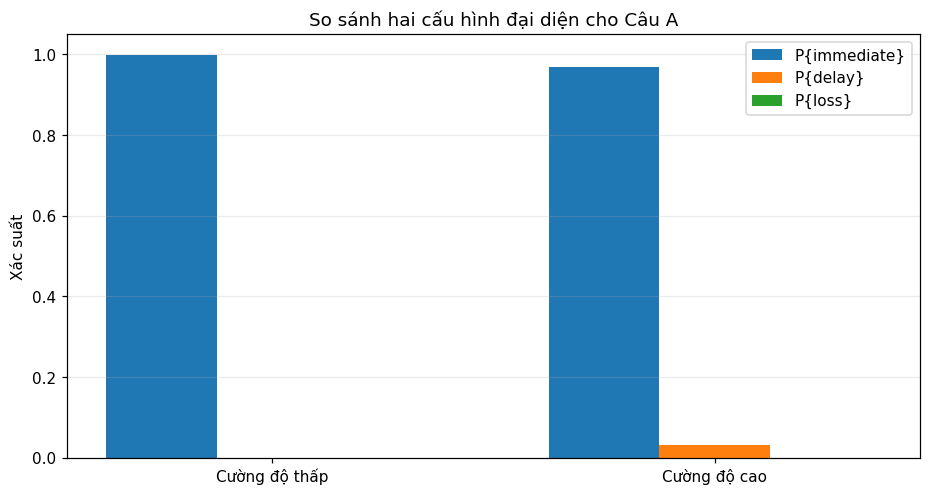

In [18]:
x = np.arange(len(rep_df))
width = 0.25

plt.bar(x - width, rep_df["P{immediate}"], width=width, label="P{immediate}")
plt.bar(x, rep_df["P{delay}"], width=width, label="P{delay}")
plt.bar(x + width, rep_df["P{loss}"], width=width, label="P{loss}")
plt.xticks(x, rep_df["Trường hợp"])
plt.ylim(0, 1.05)
plt.ylabel("Xác suất")
plt.title("So sánh hai cấu hình đại diện cho Câu A")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


### Câu B — Giải thích trường hợp `A = 3`

Với `A = 3`, `tm = 3` thì `λ = 1` và `μ = 1/3`.
Khi `N = n = 5`, số nguồn đúng bằng số server nên mọi arrival thực sự chỉ xảy ra ở các trạng thái
`x < 5`. Tại `x = 5` thì `λ_x = λ (N - x) = 0`, tức không còn nguồn rỗi để sinh thêm khách mới,
nên không thể xuất hiện delayed arrival. Vì vậy `P{immediate service} = 1`.

Khi tăng `N = 6, 7, 8, ...`, hệ thống bắt đầu cho phép arrival xảy ra ngay cả lúc `x >= n`.
Điều này làm xuất hiện delayed service, nên `P{immediate service}` giảm rất nhanh.


In [19]:
A_case_b = 3
N_sweep = np.arange(n, K + 1)

case_b_rows = []
for N_value in N_sweep:
    _, out = build_mmnkn_table(A=A_case_b, n=n, tm=tm, K=K, N=int(N_value))
    case_b_rows.append(
        {
            "N": int(N_value),
            "P_immediate": out["P_immediate_service"],
            "P_delay": out["P_delayed_service"],
            "P_loss": out["P_loss"],
            "E_q": out["E_q_all_states"],
            "E_x": out["E_x"],
        }
    )

case_b_df = pd.DataFrame(case_b_rows)
case_b_df


,N,P_immediate,P_delay,P_loss,E_q,E_x
0,5,1.000000,0.000000,0.000000,0.000000,3.750000
1,6,0.762695,0.237305,0.000000,0.206233,4.551558
2,7,0.450045,0.549955,0.000000,0.713111,5.428278
3,8,0.211256,0.788744,0.000000,1.470871,6.367718
4,9,0.080559,0.919441,0.000000,2.375274,7.343819
5,10,0.025491,0.974509,0.000000,3.344282,8.336070
6,11,0.006841,0.993159,0.000000,4.335822,9.333955
7,12,0.001588,0.998412,0.000000,5.333833,10.333458
8,13,0.000325,0.999675,0.000000,6.333423,11.333356
9,14,0.000059,0.999941,0.000000,7.333348,12.333337


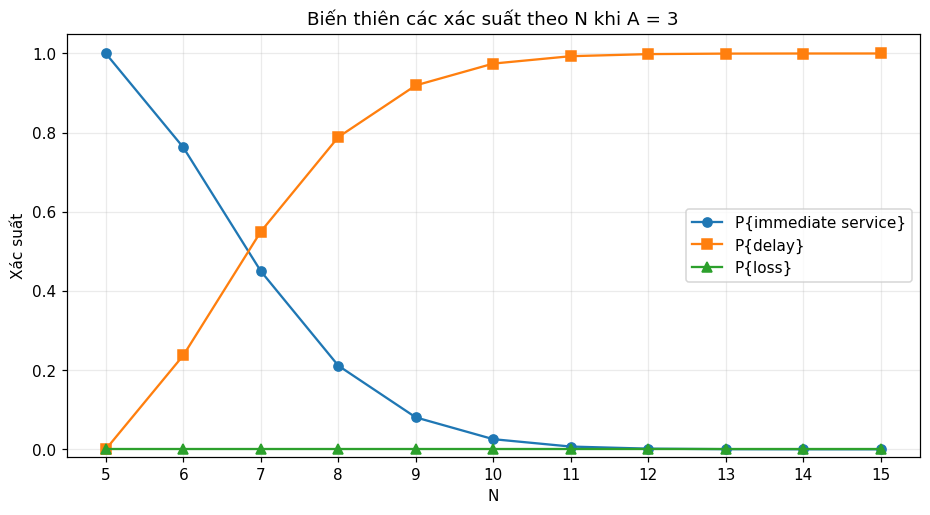

In [20]:
plt.plot(case_b_df["N"], case_b_df["P_immediate"], "o-", label="P{immediate service}")
plt.plot(case_b_df["N"], case_b_df["P_delay"], "s-", label="P{delay}")
plt.plot(case_b_df["N"], case_b_df["P_loss"], "^-", label="P{loss}")
plt.xlabel("N")
plt.ylabel("Xác suất")
plt.title("Biến thiên các xác suất theo N khi A = 3")
plt.xticks(case_b_df["N"])
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


In [21]:
# So sánh trực quan cơ chế arrival giữa N=5 và N=6
table_n5, _ = build_mmnkn_table(A=A_case_b, n=n, tm=tm, K=K, N=5)
table_n6, _ = build_mmnkn_table(A=A_case_b, n=n, tm=tm, K=K, N=6)

compare_arrival = pd.DataFrame(
    {
        "x": table_n6["x"],
        "λ_x P_x (N=5)": table_n5.reindex(range(len(table_n6)), fill_value=0)["lambda_x*P_x"],
        "λ_x P_x (N=6)": table_n6["lambda_x*P_x"],
    }
)
compare_arrival


,x,λ_x P_x (N=5),λ_x P_x (N=6)
0,0,0.004883,0.001414
1,1,0.058594,0.021217
2,2,0.263672,0.127304
3,3,0.527344,0.381913
4,4,0.395508,0.572870
5,5,0.000000,0.343722
6,6,0.000000,0.000000


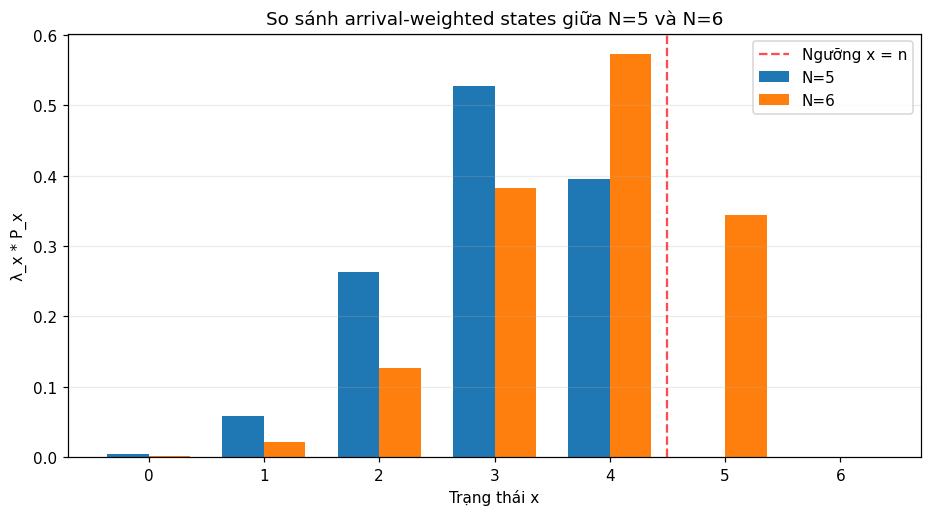

In [22]:
width = 0.36
x = compare_arrival["x"].to_numpy()

plt.bar(x - width / 2, compare_arrival["λ_x P_x (N=5)"], width=width, label="N=5")
plt.bar(x + width / 2, compare_arrival["λ_x P_x (N=6)"], width=width, label="N=6")
plt.axvline(x=n - 0.5, color="red", linestyle="--", alpha=0.7, label="Ngưỡng x = n")
plt.xlabel("Trạng thái x")
plt.ylabel("λ_x * P_x")
plt.title("So sánh arrival-weighted states giữa N=5 và N=6")
plt.xticks(x)
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.show()


---
## Câu hỏi thảo luận

Trả lời các câu hỏi sau trong báo cáo:

**Q1:** Phân biệt `P{x<n}` và `P{immediate service}`. Hai đại lượng này có giống nhau không?

**Q2:** Khi tăng `n` nhưng giữ nguyên `A, tm, K, N`, các chỉ số `P{delay}`, `P{loss}`, `E{q}` thay đổi như thế nào?

**Q3:** So sánh trường hợp `N=0` (nguồn vô hạn) với `N>0` (nguồn hữu hạn). Ảnh hưởng của số nguồn tới `λ_x` và `P_x` là gì?

**Q4:** Từ heatmap ở Câu A, hãy nêu nhận xét về vai trò của `A` và `N` đối với `P{immediate service}`.

**Q5:** Từ biểu đồ ở Câu B, hãy giải thích vì sao khi `N = n` thì không xuất hiện delayed arrival, nhưng khi `N > n` thì delayed arrival xuất hiện ngay.


---
*Hết bài lab 2.*
